# kNN Model

### We use a kNN model which is a supervised learning classifier that uses proximity to make classifications. An observation is classified based on those around it.  

In [2]:
# kNN model here
# test out diff hyperparameters like k, distance metric, weights
# try out diff distance metrics to do 

import pandas as pd 
import joblib

X_train = pd.read_csv('../data/X_train_scaled.csv')
X_test = pd.read_csv('../data/X_test_scaled.csv')
Y_train = pd.read_csv('../data/Y_train.csv') 
Y_test = pd.read_csv('../data/Y_test.csv')

# since these are loaded as DataFrames convert into 1D arrays 
y_train = Y_train.squeeze()
y_test = Y_test.squeeze()

# we will also load in our label encoder
label_encoder = joblib.load(
    '../data/label_encoder.pkl'
)

Now we'll train a baseline model with k = 5

In [3]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

### Metrics and Visualization
And let's get some metrics...
We'll use macro because we have multiple genres that aren't perfectly balanced and macro averaging treats them all equaly

Accuracy: 0.434971098265896
Precision: 0.42951198622328224
Recall: 0.42298731301713427
F1: 0.4189112897011537


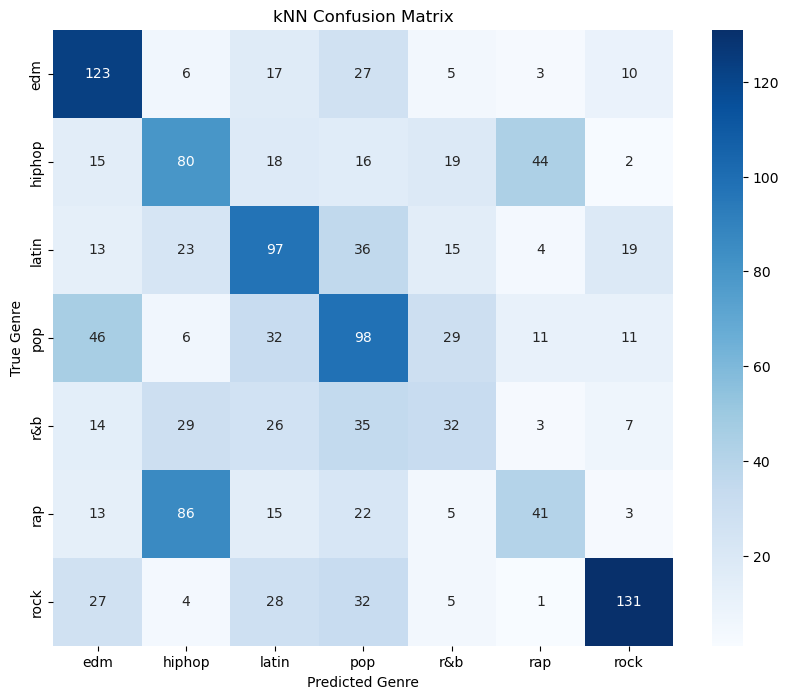

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

genre_labels = label_encoder.classes_

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred, average='macro')

recall = recall_score(y_test, y_pred, average='macro')

f1 = f1_score(y_test, y_pred, average='macro')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=genre_labels,
    yticklabels=genre_labels
)

plt.title("kNN Confusion Matrix")
plt.xlabel("Predicted Genre")
plt.ylabel("True Genre")

plt.savefig("../figures/worse_knn_model.png", dpi=300, bbox_inches="tight")

plt.show()




Now let's try a couple of different k values...and plot the differences 

Highest Test Accuracy: 0.5036
Best k: 28


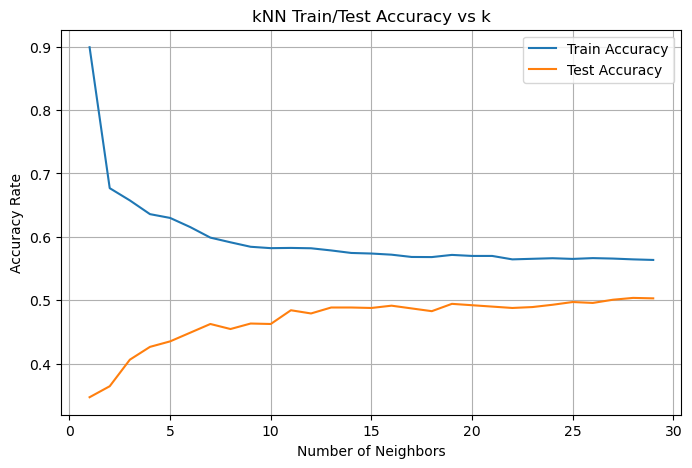

In [11]:

k_values = range(1, 30)

train_accs = []
test_accs = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    train_pred = knn.predict(X_train)
    test_pred = knn.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    train_accs.append(train_acc)
    test_accs.append(test_acc)

plt.figure(figsize=(8, 5))
plt.plot(k_values, train_accs, label='Train Accuracy')
plt.plot(k_values, test_accs, label='Test Accuracy')

plt.title("kNN Train/Test Accuracy vs k")
plt.xlabel("Number of Neighbors")
plt.ylabel("Accuracy Rate")
plt.legend()
plt.grid(True)

highest_acc = max(test_accs)

best_k = k_values[test_accs.index(highest_acc)]

print(f"Highest Test Accuracy: {highest_acc:.4f}")
print(f"Best k: {best_k}")

plt.savefig("../figures/k-value-test-knn.png", dpi=300, bbox_inches="tight")

plt.show()

We can see from this graph at k = 1 the model basically memorizes the training set since for every training point its nearest neighbor is itself. This explains the gap between train and test accuracy at this point. As k increases the predictions become more averaged across more neighbors and the decision boundary smooths out. Training accuracy drops and test accuracy improves. 

### Testing Different Distance Metrics 
This metric determines how we measure similarity between songs. Different metrics changes the shape of closeness. The default is Euclidean Distance that is an ordinary straight line distance. It is sensitive to large feature differences and works best when they are standarized, which we have done in preprocessing. It makes circular neighborhoods. 

There is also Manhattan Distance that adds absolute differences so it's less sensitive to outliers and more robust when some features are wildly different. It makes diamond-shaped neighborhoods. 

Finally there is Minkowski Distance which is just a generalized distance metric that has a parameter p involved which can make the model more or less sensitive to large features differences. A high p increases this. 

In [6]:
metrics = ['euclidean', 'manhattan']

for metric in metrics:
    knn = KNeighborsClassifier(
        n_neighbors=10,
        metric=metric
    )

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(metric, acc)

p_values = [1, 2, 3, 4]

for p in p_values: 
    knn = KNeighborsClassifier(
        n_neighbors=10,
        metric='minkowski',
        p=p
    )
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(f"p={p}: {acc}")

    

euclidean 0.4624277456647399
manhattan 0.47109826589595377
p=1: 0.47109826589595377
p=2: 0.4624277456647399
p=3: 0.45736994219653176
p=4: 0.44508670520231214


As we can see from the metric results, manhatten and minkowski with p = 2 performs the best, slightly above p=1 and euclidean. If we emphasize feature differences more strongly with higher p values, our accuracy appears to drop. 

Highest Test Accuracy: 0.5195
Best k: 28


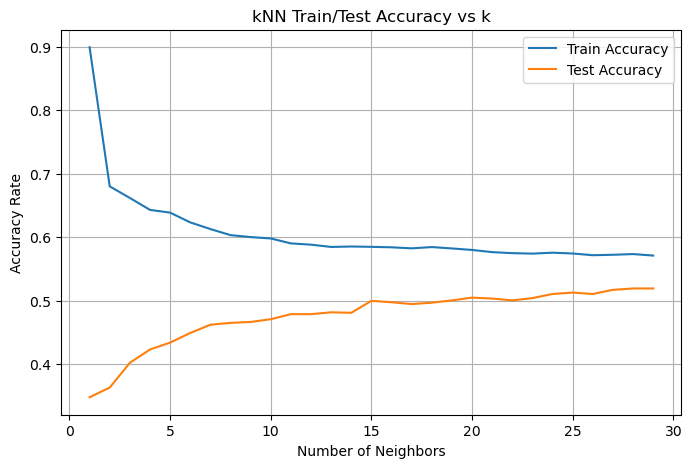

In [15]:
k_values = range(1, 30)

train_accs = []
test_accs = []

for k in k_values:
    knn = KNeighborsClassifier(
        n_neighbors=k, 
        metric='manhattan'
        )
    knn.fit(X_train, y_train)

    train_pred = knn.predict(X_train)
    test_pred = knn.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    train_accs.append(train_acc)
    test_accs.append(test_acc)

plt.figure(figsize=(8, 5))
plt.plot(k_values, train_accs, label='Train Accuracy')
plt.plot(k_values, test_accs, label='Test Accuracy')


plt.title("kNN Train/Test Accuracy vs k")
plt.xlabel("Number of Neighbors")
plt.ylabel("Accuracy Rate")
plt.legend()
plt.grid(True)

highest_acc = max(test_accs)

best_k = k_values[test_accs.index(highest_acc)]

print(f"Highest Test Accuracy: {highest_acc:.4f}")
print(f"Best k: {best_k}")

plt.savefig("../figures/best-knn-model-accuracy.png", dpi=300, bbox_inches="tight")

plt.show()

Best k: 28
Accuracy: 0.5195
Precision: 0.5206
Recall: 0.5087
F1 Score: 0.5074


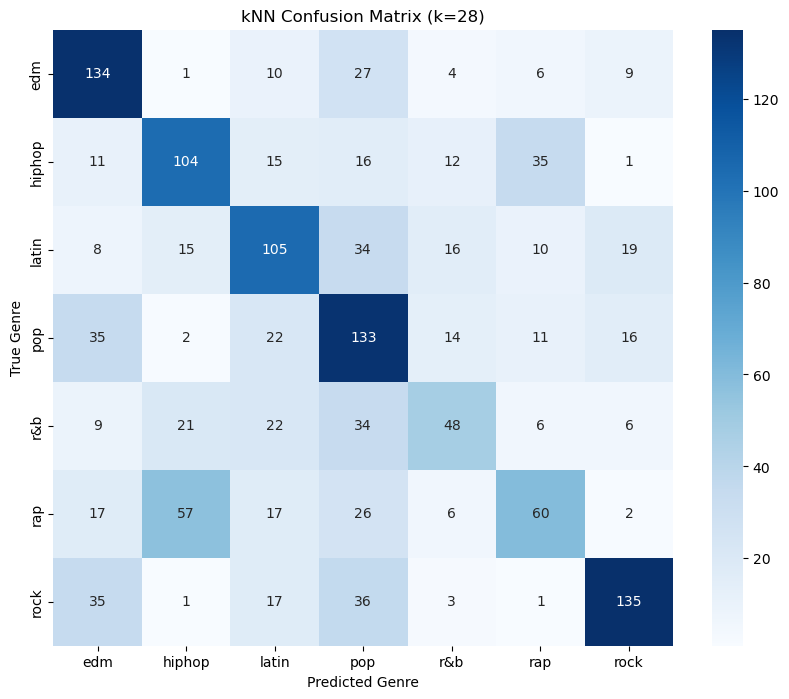

In [16]:
# retrain best model
best_knn = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='manhattan'
)

best_knn.fit(X_train, y_train)

# predictions from best model
best_pred = best_knn.predict(X_test)

# metrics
# metrics
accuracy = accuracy_score(y_test, best_pred)
precision = precision_score(y_test, best_pred, average='macro')
recall = recall_score(y_test, best_pred, average='macro')
f1 = f1_score(y_test, best_pred, average='macro')

print(f"Best k: {best_k}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# confusion matrix
cm = confusion_matrix(y_test, best_pred)

# genre labels
genre_labels = label_encoder.classes_

# plot confusion matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=genre_labels,
    yticklabels=genre_labels
)

plt.title(f"kNN Confusion Matrix (k={best_k})")
plt.xlabel("Predicted Genre")
plt.ylabel("True Genre")

plt.savefig("../figures/best_knn_model.png", dpi=300, bbox_inches="tight")

plt.show()

From this output it looks like using the Manhattan Distance overall slightly outperforms the regular Euclidean Distance. This could stem from the fact that some songs could differ mainly in just one feature, where Euclidean squares that difference and it starts to dominate. Manhatten just takes the absolute value of the difference and adds it so all features contribute more evenly. This can help since genres tend to have feature overlaps and no single feature should dominate similarity calculations. 

### Final Results: 

Based on just the highest test accuracy k = 28 performs the best with the Manhattan Distance metric. The accuracy is about 52%. This signals to us that kNN is not the best model for this job since separating genre's based on features may be more complex than what kNN can achieve. 

### Why kNN isn't Super Accurate
We can use PCA to display the overlap that genres experience in the feature space. 

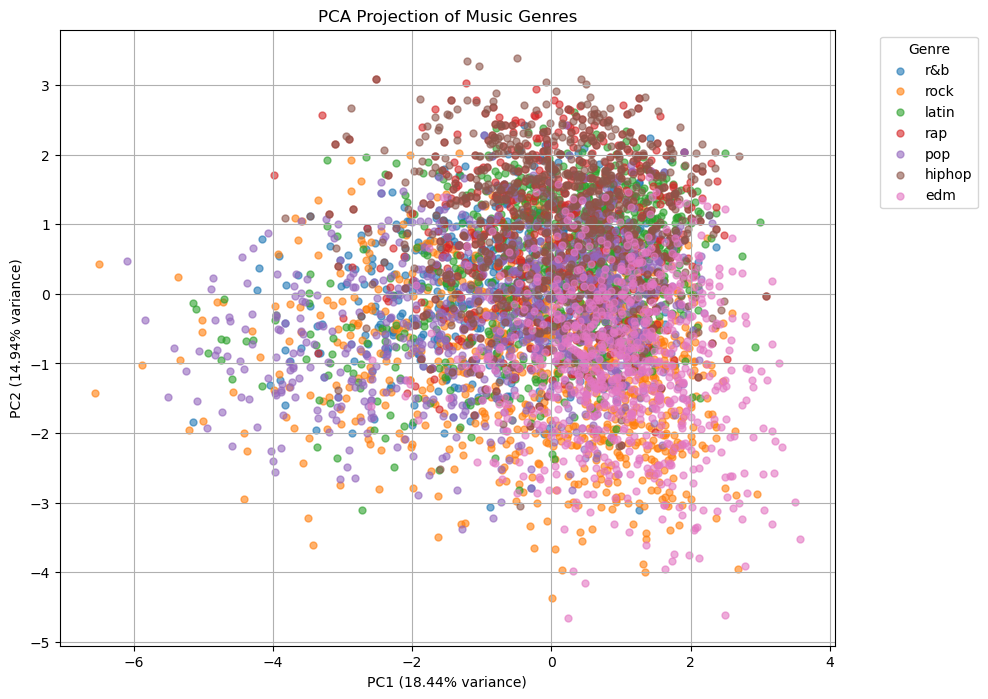

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# reduce 11 features into 2 principal components
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

# make dataframe for plotting
pca_df = pd.DataFrame(
    X_train_pca,
    columns=["PC1", "PC2"]
)

# convert encoded labels back to genre names
pca_df["Genre"] = label_encoder.inverse_transform(y_train)

plt.figure(figsize=(10, 8))

for genre in pca_df["Genre"].unique():
    genre_data = pca_df[pca_df["Genre"] == genre]

    plt.scatter(
        genre_data["PC1"],
        genre_data["PC2"],
        label=genre,
        alpha=0.6,
        s=25
    )

plt.title("PCA Projection of Music Genres")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}% variance)")
plt.legend(title="Genre", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)

plt.savefig("../figures/PCA_projection.png", dpi=300, bbox_inches="tight")
plt.show()

As we can see from this plot, condensing the 11 input features into 2 principal components only keeps abot 33% of the structure of the original 11D data. We can also see that the genres overlap a ton, making this a non-trivial problem. Rap and hip-hop appears to be completely overlapped and close to one another, while rock is further away from other genres and thus easier to classify, same with EDM.

### Using Top-3 Accuracy 
With our accuracy being so low since many genres tend to overlap a lot in features, as seen in our preprocessing step, EDA, and from plotting the feature space via PCA, we can try and get a better story regarding model usefullness if we check the top 3 guesses by the model, instead of just the top 1 and count it getting it correct if the correct genre is in that top 3. 

Highest Top-3 Test Accuracy: 0.8295
Best k: 29


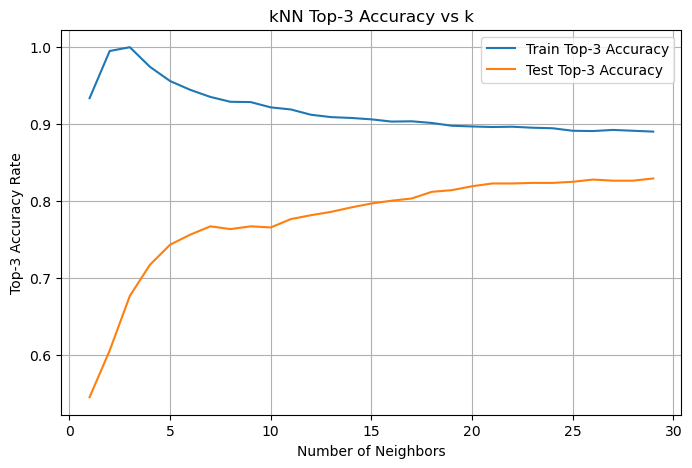

In [18]:
from sklearn.metrics import top_k_accuracy_score

k_values = range(1, 30)

train_top3_accs = []
test_top3_accs = []

for k in k_values:

    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric='manhattan'
    )

    knn.fit(X_train, y_train)

    # predicted probabilities
    train_prob = knn.predict_proba(X_train)
    test_prob = knn.predict_proba(X_test)

    # top-3 accuracies
    train_top3_acc = top_k_accuracy_score(
        y_train,
        train_prob,
        k=3
    )

    test_top3_acc = top_k_accuracy_score(
        y_test,
        test_prob,
        k=3
    )


    train_top3_accs.append(train_top3_acc)
    test_top3_accs.append(test_top3_acc)

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    train_top3_accs,
    label='Train Top-3 Accuracy'
)

plt.plot(
    k_values,
    test_top3_accs,
    label='Test Top-3 Accuracy'
)

plt.title("kNN Top-3 Accuracy vs k")
plt.xlabel("Number of Neighbors")
plt.ylabel("Top-3 Accuracy Rate")

plt.legend()
plt.grid(True)


highest_acc = max(test_top3_accs)
best_k = k_values[test_top3_accs.index(highest_acc)]

print(f"Highest Top-3 Test Accuracy: {highest_acc:.4f}")
print(f"Best k: {best_k}")

plt.savefig("../figures/top-3-accuracy-knn.png", dpi=300, bbox_inches="tight")

plt.show()

As we can see here, we are able to achieve a much higher accuracy when we use top-3 margins instead. 